### Tarefa 2 M14

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set_theme(style="whitegrid")

In [10]:
def plota_pivot_table(df, value, index, func, title, ylabel, xlabel, target_dir):
    pivot = pd.pivot_table(df, values=value, index=index, aggfunc=func)
    pivot.plot(figsize=[15, 5])
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.title(title)
    
    os.makedirs(target_dir, exist_ok=True)
    plt.savefig(os.path.join(target_dir, f'{title}.png'))
    plt.show() # Mostra o gráfico no notebook
    plt.close()

Processando mês: MAR


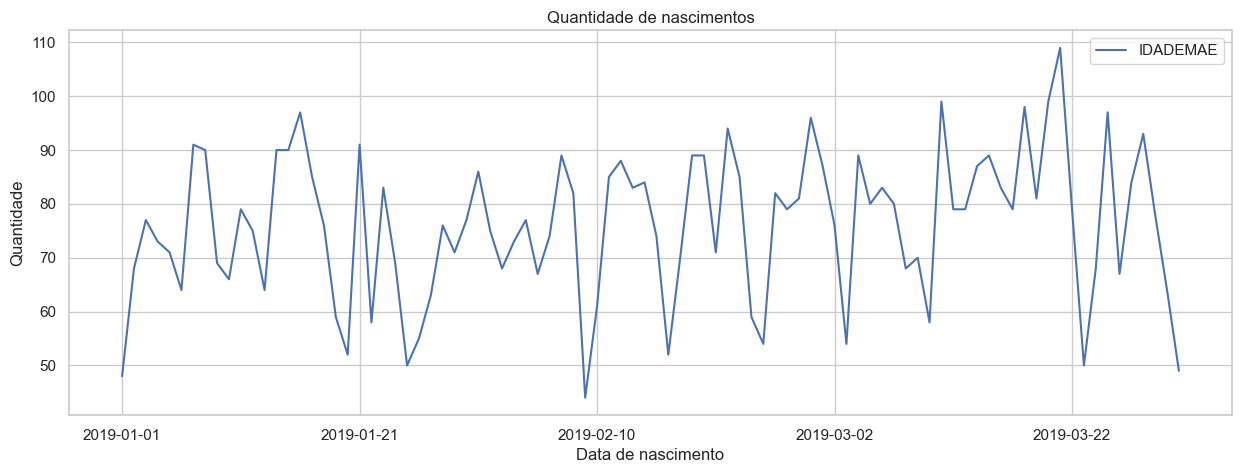

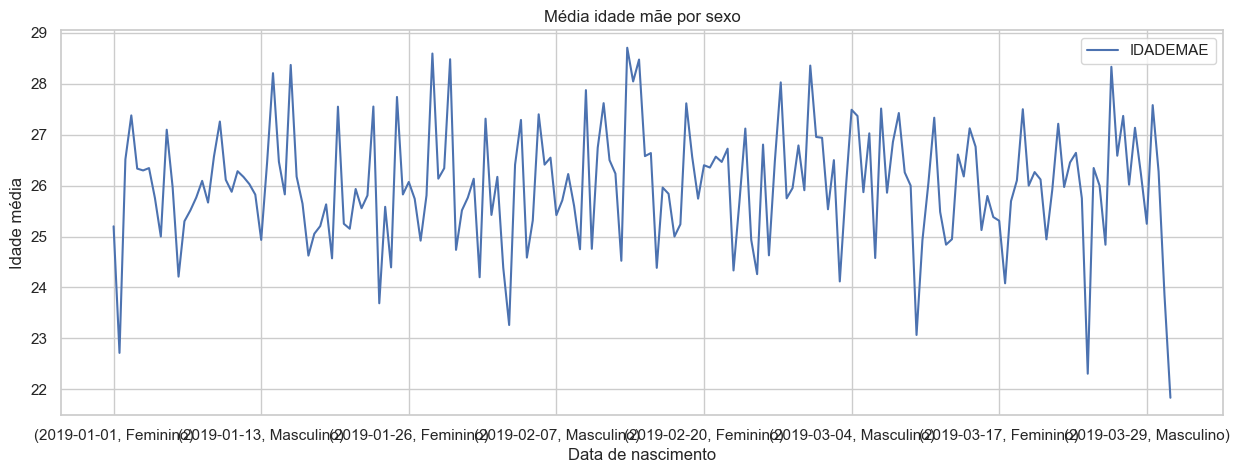

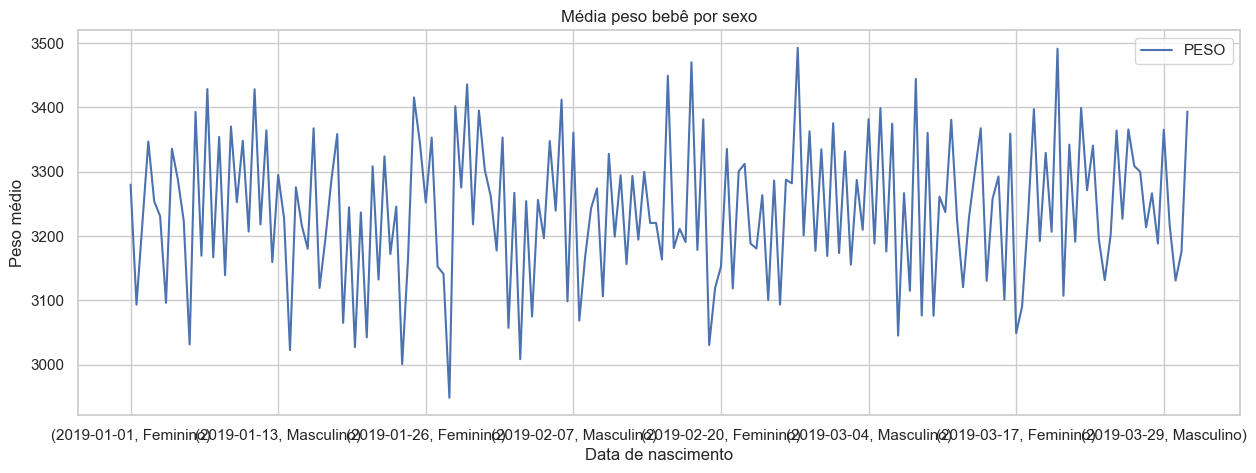

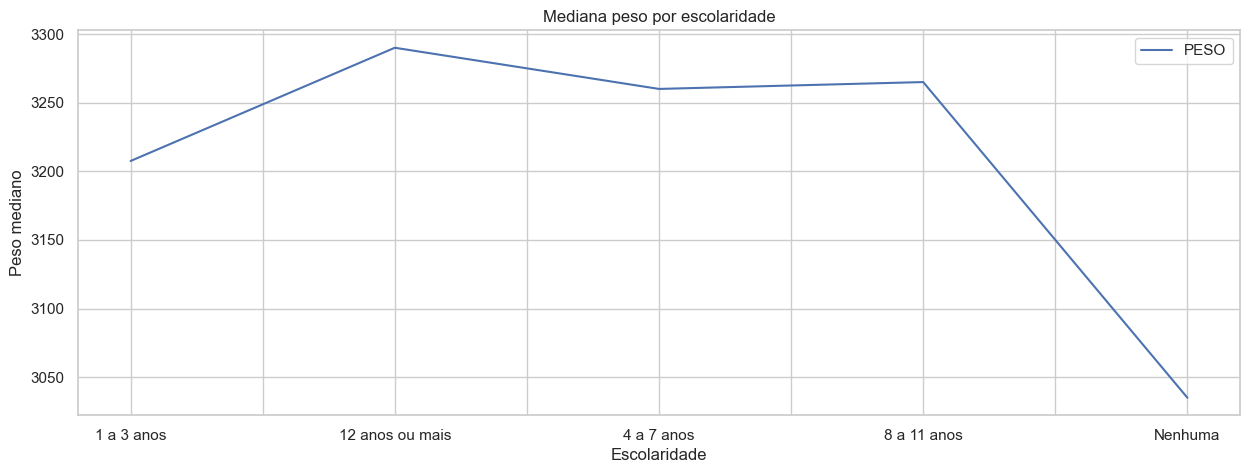

KeyError: 'ESTCIVMAE'

In [11]:
# Lista de meses solicitada na tarefa
meses = ['MAR', 'ABR', 'MAI', 'JUN', 'DEZ']

for mes in meses:
    arquivo = f'SINASC_RO_2019_{mes}.csv'
    
    if os.path.exists(arquivo):
        print(f"Processando mês: {mes}")
        sinasc = pd.read_csv(arquivo)
        
        # Identifica a data máxima para nomear a pasta
        data_maxima = sinasc.DTNASC.max()
        diretorio_saida = f'./output/{data_maxima}'
        
        # Gera os 5 gráficos solicitados
        plota_pivot_table(sinasc, 'IDADEMAE', 'DTNASC', 'count', 'Quantidade de nascimentos', 'Quantidade', 'Data de nascimento', diretorio_saida)
        plota_pivot_table(sinasc, 'IDADEMAE', ['DTNASC', 'SEXO'], 'mean', 'Média idade mãe por sexo', 'Idade média', 'Data de nascimento', diretorio_saida)
        plota_pivot_table(sinasc, 'PESO', ['DTNASC', 'SEXO'], 'mean', 'Média peso bebê por sexo', 'Peso médio', 'Data de nascimento', diretorio_saida)
        plota_pivot_table(sinasc, 'PESO', 'ESCMAE', 'median', 'Mediana peso por escolaridade', 'Peso mediano', 'Escolaridade', diretorio_saida)
        plota_pivot_table(sinasc, 'IDADEMAE', 'ESTCIVMAE', 'mean', 'Média idade mãe por estado civil', 'Idade média', 'Estado civil', diretorio_saida)
        
    else:
        print(f"Arquivo {arquivo} não encontrado na pasta atual.")